好的，很高兴你对我研究的领域感兴趣。我是MIT的教授，专注于深度学习的基础模型与历史演进。LeNet是一个绝佳的起点，它不仅是卷积神经网络的奠基者，也完美地体现了深度学习中的核心思想。

今天，我将为你详细拆解LeNet，就像我在给研究生上深度学习历史课一样。我们会深入探讨它的**设计动机、网络架构、关键创新以及历史意义**。

---

### 1. 历史背景与要解决的问题

在20世纪80-90年代，主流的手写数字识别方法依赖于**手工设计的特征提取器**（如边缘检测、角点检测）和**传统的分类器**（如支持向量机SVM）。这种方法存在一个根本性问题：**特征工程需要大量的领域知识，且设计出的特征泛化能力有限**。

**LeNet的诞生**：由Yann LeCun、Léon Bottou、Yoshua Bengio和Patrick Haffner在1998年发表的论文《Gradient-Based Learning Applied to Document Recognition》中提出。其核心目标是：
> **让机器自动从数据中学习特征，而不是依赖人工设计。**

他们选择的应用场景是**银行支票上的手写数字识别（MNIST数据集的前身）**。这是一个非常实际且具有挑战性的问题。

### 2. LeNet-5 架构详解

我们通常所说的LeNet指的是其最成熟的版本——**LeNet-5**（“5”表示有5个可学习的层）。下图是其经典架构，我们将逐层分析：

```
Input (32x32) -> [C1: 6@28x28] -> [S2: 6@14x14] -> [C3: 16@10x10] -> [S4: 16@5x5] -> [C5: 120] -> [F6: 84] -> Output(10)
```

让我们来详细分解每一层：

#### **第0层：输入层**
*   **尺寸**： 32x32 像素的灰度图像。
*   **为什么是32x32？** 原始数据集的图像大小不一，需要被归一化到这个尺寸。选择32x32而不是28x28（MNIST标准）是为了在卷积后让特征图的尺寸不至于太小，保留更多信息。

#### **第1层：卷积层**
*   **名称**： C1
*   **操作**： 卷积
*   **参数**：
    *   卷积核数量：6个
    *   卷积核尺寸：5x5
    *   步长：1
    *   填充：0（在当时，显式填充不常用）
*   **输出特征图尺寸计算**： `(32 - 5) / 1 + 1 = 28`。所以输出是 **6个 28x28 的特征图**。
*   **核心思想**： 每个5x5的卷积核在输入图像上滑动，学习一种特定的局部特征（例如，某个方向的笔画、拐角等）。6个卷积核就意味着网络在这一层学习了6种不同的基础特征。

#### **第2层：池化层**
*   **名称**： S2
*   **操作**： **平均池化**
*   **参数**：
    *   池化窗口大小：2x2
    *   步长：2
*   **输出特征图尺寸计算**： `28 / 2 = 14`。所以输出是 **6个 14x14 的特征图**。
*   **核心思想**：
    1.  **降维与平移不变性**： 将2x2区域内的4个像素值取平均，输出一个值。这大大减少了参数数量和计算量。
    2.  **使特征具有轻微的位置不变性**： 即使数字在图像中偏移几个像素，池化后提取到的主要特征仍然会保留下来。
    *   *（现代网络更多使用**最大池化**，因为它能更好地保留纹理特征，但平均池化是当时的开创性尝试）*

#### **第3层：卷积层**
*   **名称**： C3
*   **操作**： 卷积
*   **参数**：
    *   卷积核数量：16个
    *   卷积核尺寸：5x5
    *   步长：1
    *   填充：0
*   **输出特征图尺寸计算**： `(14 - 5) / 1 + 1 = 10`。所以输出是 **16个 10x10 的特征图**。
*   **一个精妙的设计**： 这一层的输入是6个特征图，但并不是每个输出特征图都连接所有6个输入。作者设计了一个**稀疏连接表**，目的是打破对称性，迫使不同的特征图组合学习不同的模式。例如，某个卷积核可能只关注前3个特征图，而另一个则关注后3个。这减少了计算量和过拟合的风险。（现代实现通常简化为全连接，即每个输出通道与所有输入通道相连）。

#### **第4层：池化层**
*   **名称**： S4
*   **操作**： 平均池化
*   **参数**：
    *   池化窗口大小：2x2
    *   步长：2
*   **输出特征图尺寸计算**： `10 / 2 = 5`。所以输出是 **16个 5x5 的特征图**。

#### **第5层：全连接层**
*   **名称**： C5（在论文中仍标记为卷积层，但因其内核也是5x5，输入是5x5，所以输出是1x1，本质上等同于全连接层）
*   **操作**： 将S4层输出的16x5x5=400个节点“拉直”，连接到一个有120个神经元的长向量上。
*   **核心思想**： 开始进行高级特征的组合和全局推理，为最终的分类做准备。

#### **第6层：全连接层**
*   **名称**： F6
*   **操作**： 全连接
*   **输出**： 84个神经元。为什么是84？一种说法是，编码一个数字（0-9）的7x12=84像素的二值化模板在当时是常见的做法。
*   **激活函数**： 使用了`tanh`或`sigmoid`。（ReLU在2012年才被广泛采用）。

#### **输出层**
*   **操作**： 由10个神经元组成（对应数字0-9），使用**径向基函数**或更常见的**高斯连接**作为损失函数。现代实现中，我们直接用**全连接层 + Softmax激活函数**，输出每个类别的概率分布。

### 3. LeNet的核心创新与关键思想

1.  **端到端学习**： 这是LeNet最革命性的思想。输入是原始像素，输出是分类结果，中间的所有特征提取步骤均由网络自动学习。
2.  **特征层次结构**： 网络通过交替的卷积和池化，构建了从低级到高级的特征层次：
    *   **浅层（C1/S2）**： 学习边缘、角点等局部特征。
    *   **中层（C3/S4）**： 组合浅层特征，形成更复杂的图案，如笔画的一部分。
    *   **高层（C5/F6）**： 组合中层特征，形成完整的数字结构。
3.  **参数共享**： 卷积核在图像上共享权重。这极大地减少了参数数量（相比于全连接网络），使模型更高效，更不易过拟合，并赋予了模型平移不变性。
4.  **空间降采样（池化）**： 提供了对微小形变的不变性，并降低了计算复杂度。

### 4. 历史意义与现代视角

*   **奠基者**： LeNet是第一个成功投入商用的CNN，用于读取银行支票上的数字，证明了深度学习的实用性。
*   **“沉睡的巨人”**： 由于当时计算资源（CPU）有限、大规模数据集匮乏，CNN的潜力在随后的近20年里未被充分发掘。直到2012年，AlexNet在ImageNet竞赛中大放异彩，其核心架构与LeNet一脉相承，只是更深、更宽，并利用了GPU计算和大数据。
*   **与现代CNN的对比**：
    *   **激活函数**： LeNet使用`tanh/sigmoid`，现代网络使用**ReLU**及其变体，解决了梯度消失问题。
    *   **池化方式**： LeNet用平均池化，现代网络多用最大池化。现在也流行用**带步长的卷积**直接替代池化层。
    *   **正则化**： 当时没有Dropout、Batch Normalization等现代正则化技术。
    *   **数据量**： LeNet在几千张图像上训练，现代网络在数百万张图像上训练。

### 总结

LeNet不仅仅是一个神经网络架构，它是一套**哲学**。它告诉我们：**对于感知问题，最好的特征是从数据中自动学习出来的，而非人工预设的。** 它的“卷积-池化-全连接”范式至今仍是计算机视觉领域深度学习模型的基石。

希望这个详细的解释能帮助你透彻理解LeNet。如果你对某个细节还有疑问，比如反向传播在卷积层中具体如何计算，我们可以继续深入探讨。

GPU型号: NVIDIA GeForce RTX 3060 Laptop GPU
GPU内存: 6.4 GB
模型架构:
LeNet(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)
可训练参数数量: 61,706

开始训练。。。
Epoch: 1 | Batch: 0/469 | Loss: 2.3042
Epoch: 1 | Batch: 0/469 | Loss: 2.3042
Epoch: 1 | Batch: 100/469 | Loss: 0.8014
Epoch: 1 | Batch: 100/469 | Loss: 0.8014
Epoch: 1 | Batch: 200/469 | Loss: 0.6024
Epoch: 1 | Batch: 200/469 | Loss: 0.6024
Epoch: 1 | Batch: 300/469 | Loss: 0.6842
Epoch: 1 | Batch: 300/469 | L

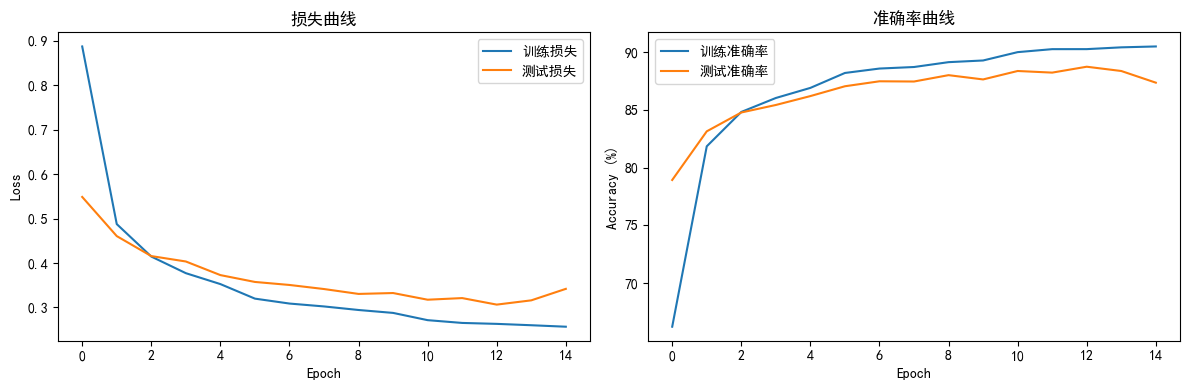

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
import time


torch.manual_seed(42)
if torch.cuda.is_available() :
    torch.cuda.manual_seed(42)
    
class LeNet(nn.Module):
    def __init__(self,num_classes = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1,out_channels=6,kernel_size=5,padding=2),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2,stride=2),
            
            nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5,padding=0),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2,stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*5*5,120),
            nn.ReLU(),
            nn.Linear(120,84),
            nn.ReLU(),
            nn.Linear(84,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
def get_data_loaders(batch_size = 10):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ])
    
    train_dataset = datasets.FashionMNIST(root='./data',train=True,download=True,transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data',train=False,download=True,transform=transform)
    
    train_loader = DataLoader(train_dataset,batch_size,shuffle=True,num_workers=2)
    test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=2)
    
    return train_loader,test_loader

def train_model(model,train_loader, criterion, optimizer, device, epoch):
    model.train()
    runing_loss = 0.0
    corrent = 0
    total = 0
    
    for batch_idx,(data,targets) in enumerate(train_loader):
        data,targets = data.to(device),targets.to(device)
        
        outputs = model(data)
        loss  = criterion(outputs,targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        
        runing_loss += loss.item()
        _,predicted = outputs.max(1)
        total += targets.size(0)
        corrent += predicted.eq(targets).sum().item()
        
        if batch_idx %100 == 0:
            print(f'Epoch: {epoch} | Batch: {batch_idx}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f}')
    
    epoch_loss = runing_loss/len(train_loader)
    epoch_acc = 100. * corrent/total
    
    return epoch_loss,epoch_acc
    
def test_model(model,test_loader,criterion,device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data,targets in test_loader:
            data,targets = data.to(device),targets.to(device)
            
            outputs = model(data)
            loss = criterion(outputs,targets)
            
            test_loss += loss.item()
            _,predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    test_loss /= len(test_loader)
    test_acc = 100 * correct / total
    return test_loss,test_acc
    

def main():
    batch_size = 128
    lr = 0.01
    num_epoch = 15
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    if torch.cuda.is_available():
         print(f'GPU型号: {torch.cuda.get_device_name(0)}')
         print(f'GPU内存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    else:
        print('使用CPU进行训练')
    
    train_loader,test_loader = get_data_loaders(batch_size)
    
    model = LeNet(10).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(),lr = lr,momentum=0.9)
    scheduler = optim.lr_scheduler.StepLR(optimizer,step_size = 5,gamma=0.5)
    
    print("模型架构:")
    print(model)
    print(f"可训练参数数量: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []
    
    print("\n开始训练。。。")
    start_time = time.time()
    for epoch in range(1,num_epoch+1) :
        epoch_start = time.time()
        
        train_loss,train_acc = train_model(model,train_loader,criterion,optimizer,device,epoch)
        test_loss,test_acc = test_model(model,test_loader,criterion,device)
        
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        
        epoch_time = time.time() - epoch_start
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        print(f'Epoch [{epoch}/{num_epoch}] | Time: {epoch_time:.2f}s | LR: {current_lr:.6f}')
        print(f'训练损失: {train_loss:.4f} | 训练准确率: {train_acc:.2f}%')
        print(f'测试损失: {test_loss:.4f} | 测试准确率: {test_acc:.2f}%')
        print('-' * 60)
    
    total_time = time.time() - start_time
    print(f'训练完成! 总时间: {total_time:.2f}秒')
    
    # 解决matplotlib中文显示问题
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体
    plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题

    # 修改绘图部分，确保所有张量都移动到CPU并转换为NumPy数组
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    # 将GPU张量转换为CPU的NumPy数组
    train_losses_cpu = [loss.cpu().item() if torch.is_tensor(loss) else loss for loss in train_losses]
    test_losses_cpu = [loss.cpu().item() if torch.is_tensor(loss) else loss for loss in test_losses]

    plt.plot(train_losses_cpu, label='训练损失')
    plt.plot(test_losses_cpu, label='测试损失')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('损失曲线')

    plt.subplot(1, 2, 2)
    # 同样处理准确率数据
    train_accs_cpu = [acc.cpu().item() if torch.is_tensor(acc) else acc for acc in train_accs]
    test_accs_cpu = [acc.cpu().item() if torch.is_tensor(acc) else acc for acc in test_accs]

    plt.plot(train_accs_cpu, label='训练准确率')
    plt.plot(test_accs_cpu, label='测试准确率')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('准确率曲线')

    plt.tight_layout()
    plt.show()
    
# 类别名称对应关系（用于可视化）
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

if __name__ == '__main__':
    main()